---
title: "CS 546: Homework 3"
author: "Trent VanHawkins"
date: today
format: 
    pdf:
        geometry: "margin=0.75in"
        mathspec: true
        code-overflow: wrap
        cap-location: bottom
        tbl-cap-location: bottom
        header-includes: 
        - \usepackage{fancyhdr, amsthm, amssymb,amsfonts,amsthm, amsmath, bbm}
        - \usepackage{float, tabularx}
        - \floatplacement{table}{H}
        - \pagestyle{fancy}
        - \fancyhead[R]{Homework 3}
        - \fancyhead[L]{Trent VanHawkins}
        - \fancyfoot[C]{\thepage} # Center page number at bottom of each page
page-layout: full
execute: 
  eval: true
---


In this homework assignment, you will use `igraph` to analyze a small directed graph in terms of its maximum-flow properties. You will find the vertex pair in the graph with the largest network flow between them.

You will need to install cairo and igraph, and to import  cairo, igraph, and numpy.

In [58]:
import igraph as ig
import numpy as np
import pandas as pd
import cairo

Here is the code to display the PNG image `hw3-graph.png` (the same graph image that is shown in the Canvas page for Homework 3).

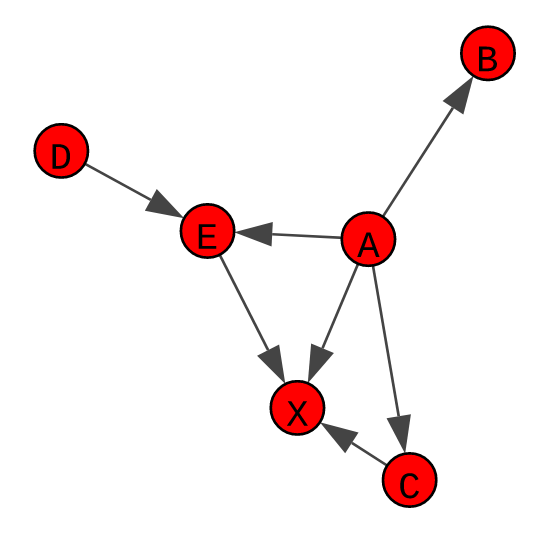

In [67]:
!wget -q https://csx46.s3-us-west-2.amazonaws.com/hw3-graph.png -O hw3-graph.png
from IPython.display import Image
Image('hw3-graph.png', width=250)

## Part 1

Define an adjacency matrix for a simple directed graph with six vertices, as shown above:


In [68]:
#Define the adjacency matrix
adj_mat = np.array([[0, 1, 1, 0, 1, 1],
                   [0, 0, 0, 0, 0, 0],
                   [0, 0, 0, 0, 0, 1],
                   [0, 0, 0, 0, 1, 0],
                   [0, 0, 0, 0, 0, 1],
                   [0, 0, 0, 0, 0, 0]])

Make an igraph graph out of this adjacency matrix, and print the graph and its summary:

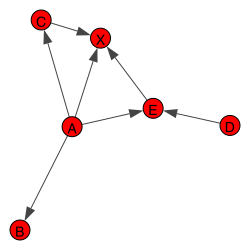

In [61]:
g = ig.Graph.Adjacency(adj_mat, mode=ig.ADJ_DIRECTED)
g.vs["label"] = ["A", "B", "C", "D", "E", "X"]
ig.drawing.plot(g, bbox=(250, 250))

Using the `igraph.Graph.maxflow` function, compute the max-flow value between all possible pairs of distinct vertices (note the word *distinct*, meaning that you should *not* compute the max-flow from a vertex to itself). Which pair of vertices have the maximum flow between them?

In [62]:
#Initialize length
n = len(g.vs)
flow = dict()

#Compute max flow in each direction
for i in range(n):
    for j in range( n):
        if i != j:
            key = str(g.vs["label"][i] + "_to_" + g.vs["label"][j])
            flow[key] = g.maxflow(i, j).value

flow["A_to_B"]

1.0

For this problem, is it necessary to check the max-flow of the vertex pair (j,i) if you have already checked the vertex pair (i,j)?  Why or why not?

*Yes. It is necessary since this is a directed graph. The max-flow from i to j may be different than the max flow from j to i. That is, it is not a symmetric matrix.*

CS546 students: Can you think of how to do it without any `for` loops?  (list comprehension allowed!)  You can show code or if you have an idea but are not quite sure of the correct syntax, you can describe your idea in words.

In [ ]:
flow_no_for = {g.vs["label"][i] + "_to_" + g.vs["label"][j]: g.maxflow(i,j).value 
               for i in range(n) for j in range(n) if i != j}

flow_no_for["A_to_B"]

1.0

## Part 2

Retrieve the file `hsmetnet.txt` from the class S3 bucket

In [64]:
!wget https://csx46.s3-us-west-2.amazonaws.com/hsmetnet.txt -O ../DataRaw/hsmetnet.txt

--2026-03-06 11:08:56--  https://csx46.s3-us-west-2.amazonaws.com/hsmetnet.txt
Resolving csx46.s3-us-west-2.amazonaws.com (csx46.s3-us-west-2.amazonaws.com)... 3.5.85.112, 3.5.80.60, 3.5.84.199, ...
Connecting to csx46.s3-us-west-2.amazonaws.com (csx46.s3-us-west-2.amazonaws.com)|3.5.85.112|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 647637 (632K) [text/plain]
Saving to: ‘../DataRaw/hsmetnet.txt’

../DataRaw/hsmetnet 100%[===================>] 632.46K  4.03MB/s    in 0.2s    

2026-03-06 11:08:57 (4.03 MB/s) - ‘../DataRaw/hsmetnet.txt’ saved [647637/647637]



Read `hsmetnet.txt` into a `pandas.DataFrame` and then use that data frame to create an `igraph.Graph` directed graph

In [ ]:
hsmetnet = pd.read_csv(filepath_or_buffer= "../DataRaw/hsmetnet.txt", 
                       sep= "\t", names= ["source", "target"]).drop_duplicates()
hs_graph = ig.Graph.TupleList(hsmetnet.values.tolist(), directed= True)

Get the list of vertex names

In [73]:
vertex_names = hs_graph.vs["name"]

Use `List.index` twice, in order to get the positions of `alpha-D-glucose` and `pyruvate` in the `vertex_names` list; use these index positions as the source and target arguments to `igraph.Graph.maxflow_value`

In [74]:
hs_graph.maxflow_value(vertex_names.index("alpha-D-glucose"), vertex_names.index("pyruvate"))

5.0

Why do you think that this pair of vertices has such a high maximum flow?  (hint: search on "glycolysis").

*The Glycolysis metabolic pathway converts glucose to pyruvate through a seriew of intermediate metabolites.*